<div class="alert alert-block alert-success">
<b>Comentario general del revisor</b> <a class="tocSkip"></a><br />
Status del proyecto: <b>Aprobado</b>
</div>


¡Hola!<br />
Soy **Francisco Cortés**, estoy contento de revisar tu proyecto y ser parte de tu proceso de aprendizaje.
A lo largo del texto, haré algunas observaciones sobre mejoras en el código y también haré comentarios sobre tus percepciones sobre el tema. Si existe algún error en el código, no te preocupes, estoy aquí para ayudarte a mejorarlo, en la primera iteración te lo señalaré para que tengas la oportunidad de corregirlo, pero si aún no encuentras una solución para esta tarea, te daré una pista más precisa en la próxima iteración y también algunos ejemplos prácticos. Estaré abierto a retroalimentación y discusiones sobre el tema.<br />
Encontrarás mis comentarios a continuación - **por favor no los muevas, modifiques o borres**.
Revisaré cuidadosamente tu código para comprobar que se han cumplido con los requisitos y te proporcionaré mis comentarios en cajas verdes, amarillas o rojas como esta:

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Si la ejecución fue perfecta succesfully.
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Si existe alguna recomendación para que tu código mejore.
</div>

<div class="alert alert-block alert-danger">

<b>Comentario del revisor</b> <a class="tocSkip"></a>

Si existen correcciones necesarias para cumplir con los requisitos. El trabajo no puede ser aceptado si hay alguna caja roja.
</div>

Puedes responderme de la siguiente manera:

<div class="alert alert-block alert-info">
<b>Respuesta del estudiante.</b> <a class="tocSkip"></a>
</div>

# 1.1 Inicialización

In [1]:
#Cargar todas las librerías
import numpy as np
import pandas as pd
from scipy import stats as st
import matplotlib.pyplot as plt

## 1.2 Cargar Datos

In [2]:
# Cargar los archivos de datos en un DataFrame
df_games = pd.read_csv("/datasets/games.csv")

# 2. Preparar Los Datos

In [3]:
# Imprimir la información general/resumida sobre el DataFrame
print(df_games.describe())
df_games.info()
df_games.head()

       Year_of_Release      NA_sales      EU_sales      JP_sales  \
count     16446.000000  16715.000000  16715.000000  16715.000000   
mean       2006.484616      0.263377      0.145060      0.077617   
std           5.877050      0.813604      0.503339      0.308853   
min        1980.000000      0.000000      0.000000      0.000000   
25%        2003.000000      0.000000      0.000000      0.000000   
50%        2007.000000      0.080000      0.020000      0.000000   
75%        2010.000000      0.240000      0.110000      0.040000   
max        2016.000000     41.360000     28.960000     10.220000   

        Other_sales  Critic_Score  
count  16715.000000   8137.000000  
mean       0.047342     68.967679  
std        0.186731     13.938165  
min        0.000000     13.000000  
25%        0.000000     60.000000  
50%        0.010000     71.000000  
75%        0.030000     79.000000  
max       10.570000     98.000000  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


In [4]:
# Reemplazar nombres de columnas (ponerlos en minúsculas)
df_games.columns = df_games.columns.str.lower()
print(df_games.columns)

Index(['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales',
       'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating'],
      dtype='object')


In [5]:
# Convertir los datos en los tipos necesarios
df_games["year_of_release"] = df_games["year_of_release"].astype("Int64")
df_games["critic_score"] = df_games["critic_score"].astype("Float64")
df_games["user_score"] = df_games["user_score"].replace("tbd", np.NaN)
df_games["user_score"] = np.float64(df_games["user_score"])
df_games.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16446 non-null  Int64  
 3   genre            16713 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   Float64
 9   user_score       7590 non-null   float64
 10  rating           9949 non-null   object 
dtypes: Float64(1), Int64(1), float64(5), object(4)
memory usage: 1.4+ MB


### Notas:
- year_of_realease = año de lanzamiento del video juego.
- critic_score = calificaión de los crítios ( de 0 a 100).
- user_score = la calificación que le dan los usuarios a un video juego (de 0 a 10).

Decidí convertir el año de lazamiento a tipo "Int64" debido a que es un solo número, y facilita los cálculos. Igualmente, la columna "critic_score" la transformé a entero y "user_score" la transformé a flotante; en la columna "user_score" reemplacé los valores "tbd" por valores nulos para poder transformar la columna a valores decimales

In [6]:
# Tratamiento de valores ausentes
mean_critic_score = df_games["critic_score"].mean()
df_games["critic_score"] = df_games["critic_score"].fillna(mean_critic_score)
mean_user_score = df_games["user_score"].mean()
df_games["user_score"] = df_games["user_score"].fillna(mean_user_score)
indices = df_games[df_games["name"].isna()].index.tolist()
df_games = df_games.drop(indices, axis=0)
df_games.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 16713 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16713 non-null  object 
 2   year_of_release  16444 non-null  Int64  
 3   genre            16713 non-null  object 
 4   na_sales         16713 non-null  float64
 5   eu_sales         16713 non-null  float64
 6   jp_sales         16713 non-null  float64
 7   other_sales      16713 non-null  float64
 8   critic_score     16713 non-null  Float64
 9   user_score       16713 non-null  float64
 10  rating           9949 non-null   object 
dtypes: Float64(1), Int64(1), float64(5), object(4)
memory usage: 1.6+ MB


### Notas:
- Para rellenar los valores faltantes de las colunas "critic_score" y "user_score" decidí usar la media de cada columna debido a que, basado en la descripción de los datos hecha previamente (.describre()), me doy cuenta de que no hay outliers que puedan alterar la desviación mucho, la media y la mediana son muy similares. Estos valores están ausentes por varias razones, una siendo que no se han evaluado todavía por críticos ni usuarios en plataformas oficiales.

- Respecto a los valores ausentes de la columna "year_of_realease", no tiene sentido rellenar con valores inventados, media o mediana debido a que este es un valor muy específico y no puedo solo asignar un valor cualquiera. Estos valores pueden estar ausentes por descuido al crear la base de datos o simplemente porque no se sabe exactamente su año de creación.

- Las columnas "name" y "genre" tienen solo 2 valores ausnetes, a ambas filas les hacen falta el nombre del juego y el género, no puedo inventarme un valor porque no tengo información alguna sobre esos juegos y tampoco son demasiados datos faltantes como para alterar el resultado así que los eliminaré de la base de datos.

In [7]:
#Calcular ventas totales por juego
df_games["total_sales"] = df_games[["na_sales", "eu_sales", "jp_sales", "other_sales"]].sum(axis=1)
print(df_games.head())

                       name platform  year_of_release         genre  na_sales  \
0                Wii Sports      Wii             2006        Sports     41.36   
1         Super Mario Bros.      NES             1985      Platform     29.08   
2            Mario Kart Wii      Wii             2008        Racing     15.68   
3         Wii Sports Resort      Wii             2009        Sports     15.61   
4  Pokemon Red/Pokemon Blue       GB             1996  Role-Playing     11.27   

   eu_sales  jp_sales  other_sales  critic_score  user_score rating  \
0     28.96      3.77         8.45          76.0    8.000000      E   
1      3.58      6.81         0.77     68.967679    7.125046    NaN   
2     12.76      3.79         3.29          82.0    8.300000      E   
3     10.93      3.28         2.95          80.0    8.000000      E   
4      8.89     10.22         1.00     68.967679    7.125046    NaN   

   total_sales  
0        82.54  
1        40.24  
2        35.52  
3        32.77  
4

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Bien hecho!<br/>

Hiciste un buen trabajo al cambiar los nombres de las columnas, sus tipos de datos y reemplazar los valores ausentes
</div>


# Paso 3. Analizar los datos

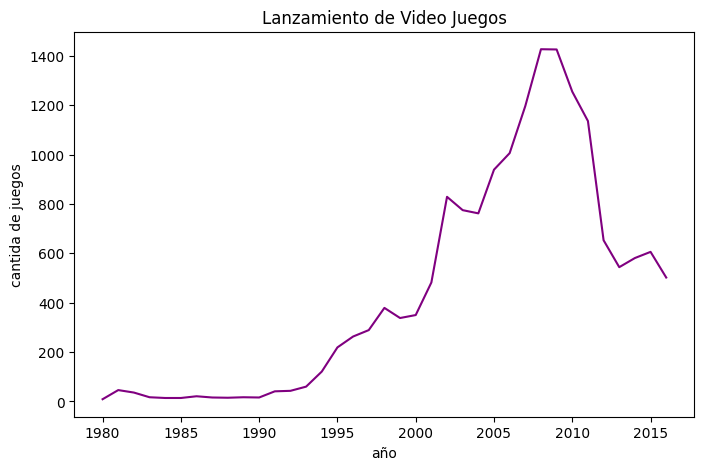

year_of_release
1980       9
1981      46
1982      36
1983      17
1984      14
1985      14
1986      21
1987      16
1988      15
1989      17
1990      16
1991      41
1992      43
1993      60
1994     121
1995     219
1996     263
1997     289
1998     379
1999     338
2000     350
2001     482
2002     829
2003     775
2004     762
2005     939
2006    1006
2007    1197
2008    1427
2009    1426
2010    1255
2011    1136
2012     653
2013     544
2014     581
2015     606
2016     502
Name: name, dtype: int64


In [8]:
# Juegos lanzados en diferentes años
juegos_por_año = df_games.groupby("year_of_release")["name"].count()
juegos_por_año.plot( color="purple", figsize=[8,5])
plt.xlabel("año")
plt.ylabel("cantida de juegos")
plt.title("Lanzamiento de Video Juegos")
plt.show()
print(juegos_por_año)

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Correcto!<br/>

Buena manera de presentar los datos, podemos ver claramente la tendencia de los videojuegos con un incremento constante en años anteriores que ha empezado a ir en declive en los últimos años
</div>


### Notas:
La cantida de juegos lanzados entre los años 1980-1993 es muy baja y más o menos constante. A partir de 1995 (más o menos), la cantida de juegos lanzados aumenta drásticamente hasta llegar a un pico en 2008 (aprox.) en donde se produgeron 1427 video juegos. A partir del 2008 la cantidad de video juegos lanzados cada año disminuye constantemente. El período actual (2016) muestra un desmejora con el período inmediatamnte anterior (2015). El período que refleja mejor el mercado actual es el compredido entre 2012 y 2015, la cantida de video juegos lanzados es similar y no varía demasiado, este es el más significativo para mi análisis, los años anteriores a este período no son significatvios porque reflejan un mercado muy diferente al acutal. (No incluyo el período actual, 2016, en el rango ya que, como se menciona en el enunciado del proyecto "los datos de 2016 pueden estar incompletos")

## 3.1. Ventas Por Plataformas

Las plataformas con mayores ventas totales son:
['PS2', 'X360', 'PS3', 'Wii', 'DS']

platform             DS     PS2     PS3     Wii    X360
year_of_release                                        
1985               0.02    0.00    0.00    0.00    0.00
2000               0.00   39.17    0.00    0.00    0.00
2001               0.00  166.43    0.00    0.00    0.00
2002               0.00  205.38    0.00    0.00    0.00
2003               0.00  184.31    0.00    0.00    0.00
2004              17.27  211.81    0.00    0.00    0.00
2005             130.14  160.66    0.00    0.00    8.25
2006             119.81  103.42   20.96  137.15   51.62
2007             146.94   75.99   73.19  152.77   95.41
2008             145.31   53.90  118.52  171.32  135.26
2009             119.54   26.40  130.93  206.97  120.29
2010              85.02    5.64  142.17  127.95  170.03
2011              26.18    0.45  156.78   59.65  143.84
2012              11.01    0.00  107.36   21.71   99.74
2013               

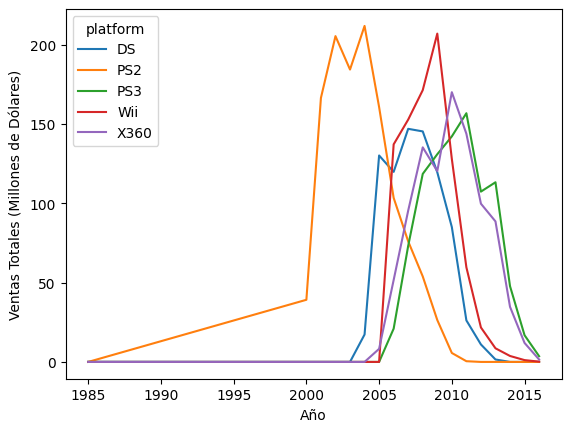

In [9]:
# Ventas por plataforma y organizarlas por ventas
ventas_por_plataforma = df_games.groupby("platform")["total_sales"].sum().sort_values(ascending=False)
top_plataformas = ventas_por_plataforma.head(5).index.tolist()

# Seleccionar el top 5 de plataformas
print(f"""Las plataformas con mayores ventas totales son:
{top_plataformas}""")
print()

# Construir una distribución de ventas por año para esas plataformas
df_games_filtrado = df_games[df_games["platform"].isin(top_plataformas)]
ventas_año_plataforma = df_games_filtrado.groupby(["platform", "year_of_release"])["total_sales"].sum().unstack(level=0, fill_value=0)
print(ventas_año_plataforma)
ventas_año_plataforma.plot()
plt.xlabel("Año")
plt.ylabel("Ventas Totales (Millones de Dólares)")
plt.show()

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Bien hecho!<br/>

Buena manera de mostrar los datos, gracias a la gráfica podemos observar el ciclo de vida de cada una de las plataformas
</div>


### Notas:
Basado con la información, las plataformas duran al rededor de unos **10-11 años** en aparecer, llegar al pico de ventas y caer o desaparecer; esto nos da claridad sobre los datos más relevantes para nuestro análisis: usaré los datos desde el _2007_ para predecir el _2017_, este será mi _período relevante_, ingnoraré los datos de los años anteriores.

#### Sobre las venta:
- DS: primeras ventas en 2004, pico de ventas en 2007, últimas ventas en 2013. Vida útil = 10 años.
- PS2: primeras ventas en 2000, pico de ventas en 2005, últimas ventas en 2011. Vida útil = 12 años
- PS3: primeras ventas en 2006, pico de ventas en 2011, últimas ventas en 2016. Vida útil = 11 años
- Wii: primeras ventas en 2006, pico de ventas en 2009, últimas ventas en 2016. Vida útil = 11 años
- X360: primeras ventas en 2005, pico de ventas en 2010, últimas ventas en 2016. Vida útil = 12 años
- **VIDA ÚTIL PROMEDIO: 11.2 años**


## 3.2. Plataformas Líderes

In [10]:
# Depuración de datos, solo usaré los datos desde 2007 hasta 2016.
# Con esta información identificaré las plataformas reelevantes
df_games_desde_2007 = df_games.query("year_of_release >= 2007")
ventas_anuales_plataforma = df_games_desde_2007.groupby(["platform", "year_of_release"])["total_sales"].sum().unstack(level=0, fill_value=0)
ventas_globales_plat = ventas_anuales_plataforma.sum().sort_values(ascending=False)
plats = ventas_globales_plat.head().index.to_list()

print(f"""Las pataformas líderes en ventas en el período de estudio son:
{plats}""")
print()
print(ventas_anuales_plataforma)


Las pataformas líderes en ventas en el período de estudio son:
['PS3', 'X360', 'Wii', 'DS', 'PS4']

platform           3DS    DC      DS  GBA    GC     PC    PS2     PS3     PS4  \
year_of_release                                                                 
2007              0.00  0.02  146.94  3.4  0.27   9.28  75.99   73.19    0.00   
2008              0.00  0.04  145.31  0.0  0.00  12.42  53.90  118.52    0.00   
2009              0.00  0.00  119.54  0.0  0.00  16.91  26.40  130.93    0.00   
2010              0.00  0.00   85.02  0.0  0.00  24.28   5.64  142.17    0.00   
2011             63.20  0.00   26.18  0.0  0.00  35.03   0.45  156.78    0.00   
2012             51.36  0.00   11.01  0.0  0.00  23.22   0.00  107.36    0.00   
2013             56.57  0.00    1.54  0.0  0.00  12.38   0.00  113.25   25.99   
2014             43.76  0.00    0.00  0.0  0.00  13.28   0.00   47.76  100.00   
2015             27.78  0.00    0.00  0.0  0.00   8.52   0.00   16.82  118.90   
2016     

### Notas:
- Las plataformas líderes en ventas durante el período de estudio (2007 - 2016) son 'PS3', 'X360', 'Wii', 'DS' y 'PS4'.
- Todas las plataformas muestran una reducción en ventas, pero las más notables son 'DS', 'DC', 'GC','PS2', 'XB', 'PSP'y 'GBA' (estas ya no tienen ventas), 'PC', 'WiiU', 'Wii', 'PSV', 'PS3', 'XB360', '3DS' (que bajaron consdirablemente sus ventas).
- Las plataformas que muestran cierta estabilidad son: **'PS4'** y **'XOne'**, aunque hayan tenido caídas considerables, tienen potencial para remontar y son potencialmente rentables teniendo en cuenta su historial

## 3.3. Diagramas de Caja

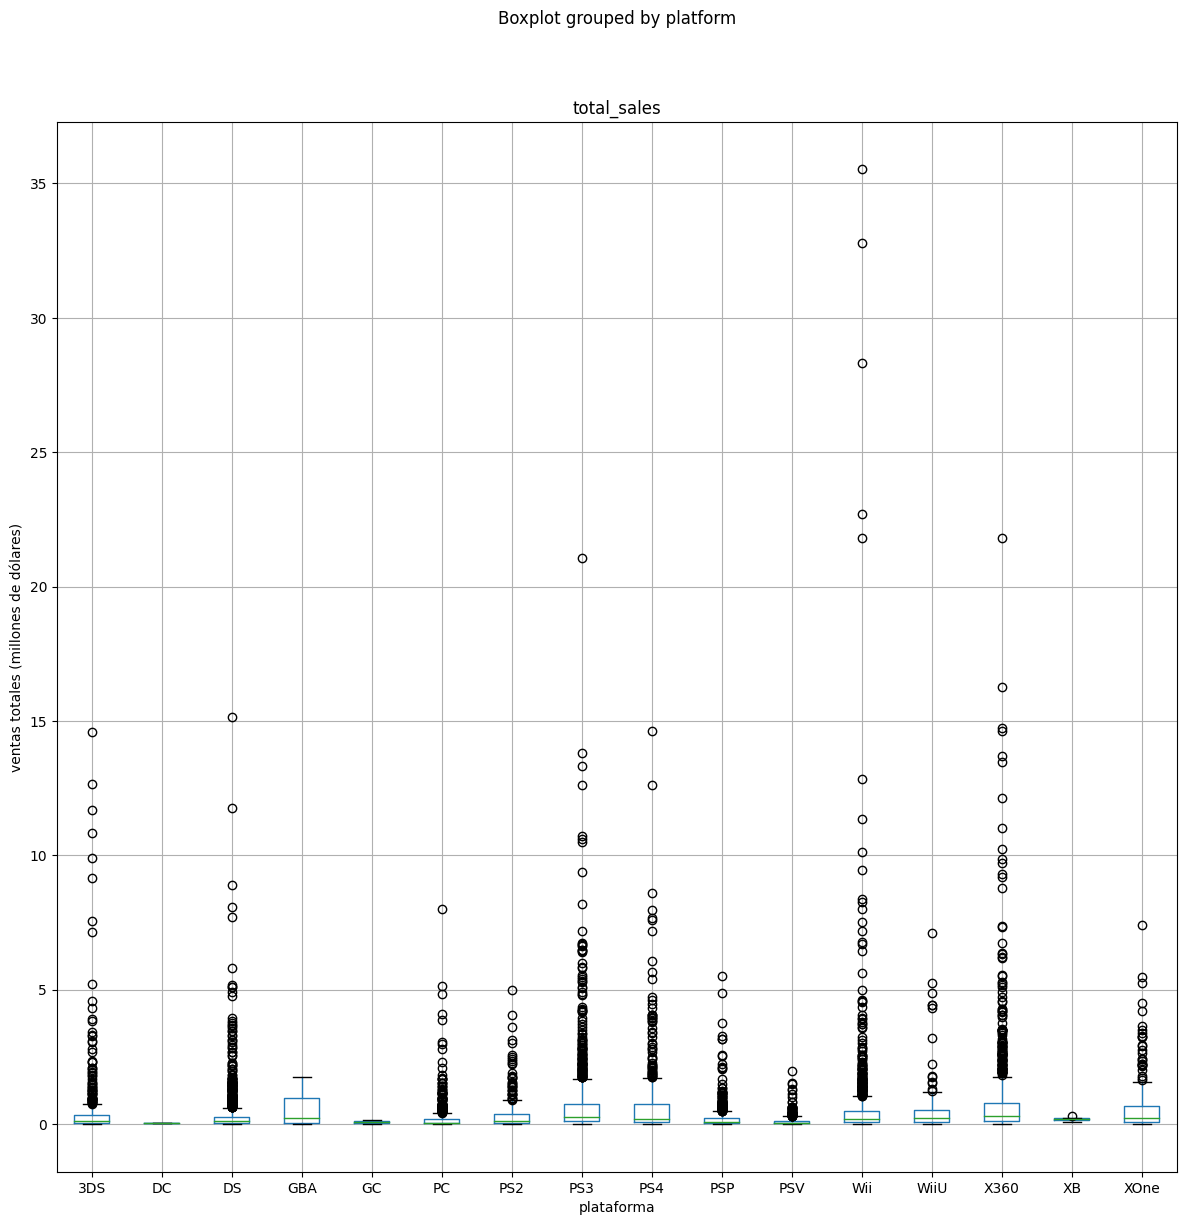

In [11]:
#Venas globales de todos los juegos
df_games_desde_2007.boxplot(column='total_sales', by='platform', figsize=(14, 14))

plt.xlabel("plataforma")
plt.ylabel("ventas totales (millones de dólares)")

plt.show()

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />

Los valores atipicos impiden que las cajas se muestren correctamente. Una manera de eliminar estos valores en la gráfica es usando `showfliers = False`. Te dejo el ejemplo en la celda de abajo
</div>


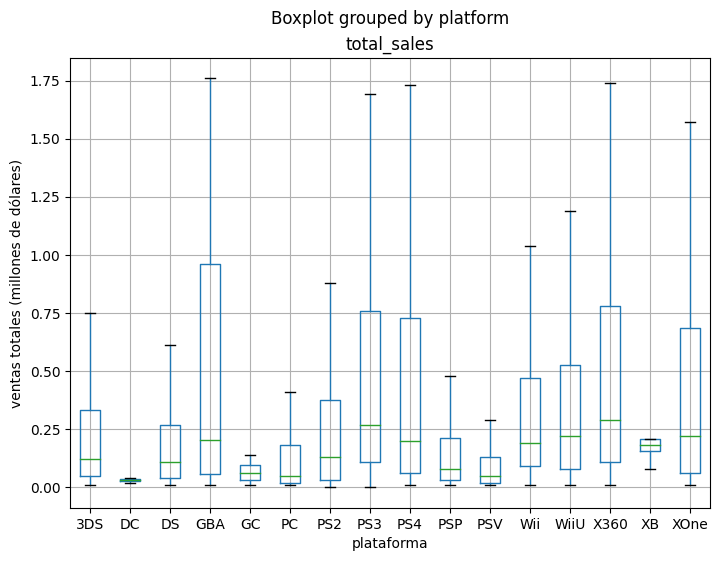

In [14]:
#Venas globales de todos los juegos
df_games_desde_2007.boxplot(column='total_sales', by='platform', figsize=(8, 6), showfliers = False)

plt.xlabel("plataforma")
plt.ylabel("ventas totales (millones de dólares)")

plt.show()

### Notas:
- Las ventas promedio de juegos en las plataformas se mantienen más o menos similares, pero observe una cantidad inmensa de outliers en la gran mayoría de las plataformas, esto indica que cada plataforma tiene juegos que fueron un exitazo y/o que un juego muy famoso fue distribuido por varias plataformas.
- Las plataformas con los outliers más altos son Wii, X360 y PS3, estas son precisamente las plataformas más competitivas actualmente.
- La plataforma GBA tiene la caja más grande, pero la media está muy baja y no tiene outliers, esto indica ventas promedio bajas pero estables durante su vida útil.
- La plataforma DC es la que tiene la caja más pequeña, esta plataforma no fue muy exitosa en términos de ventas.

## 3.4. Reseñas

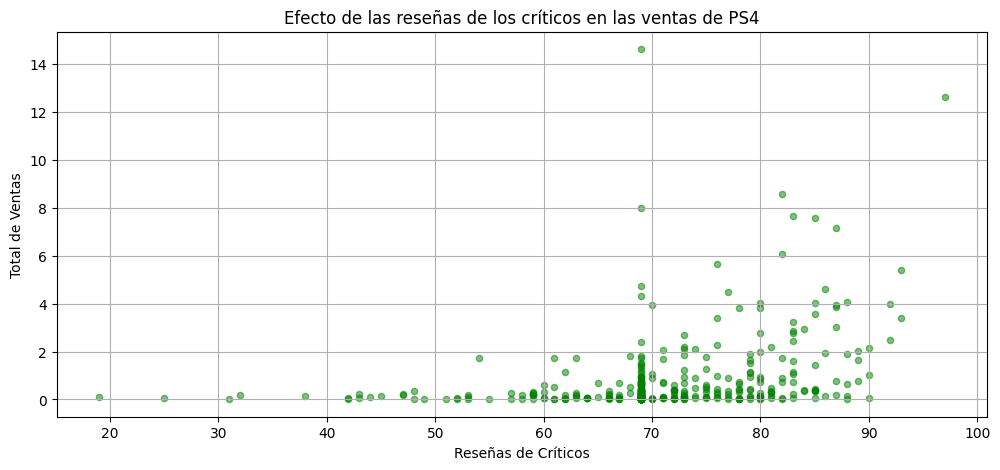


Correlación entre las reseñas de los críticos y las ventas de PS4:
              critic_score  total_sales
critic_score       1.00000      0.34901
total_sales        0.34901      1.00000


In [15]:
#Plataforma escogida = PS4
platform = "PS4"
df_plataforma = df_games_desde_2007.query("platform == @platform")

#Primero Reseñas de Críticos vs Ventas Totales
df_plataforma.plot(kind="scatter", x="critic_score", y="total_sales", alpha=0.5, color="green", figsize=(12,5))
plt.xlabel("Reseñas de Críticos")
plt.ylabel("Total de Ventas")
plt.title("Efecto de las reseñas de los críticos en las ventas de PS4")
plt.grid()
plt.show()
print()

corr_critics = df_plataforma[['critic_score', 'total_sales']].corr()
print(f"""Correlación entre las reseñas de los críticos y las ventas de PS4:
{corr_critics}""")

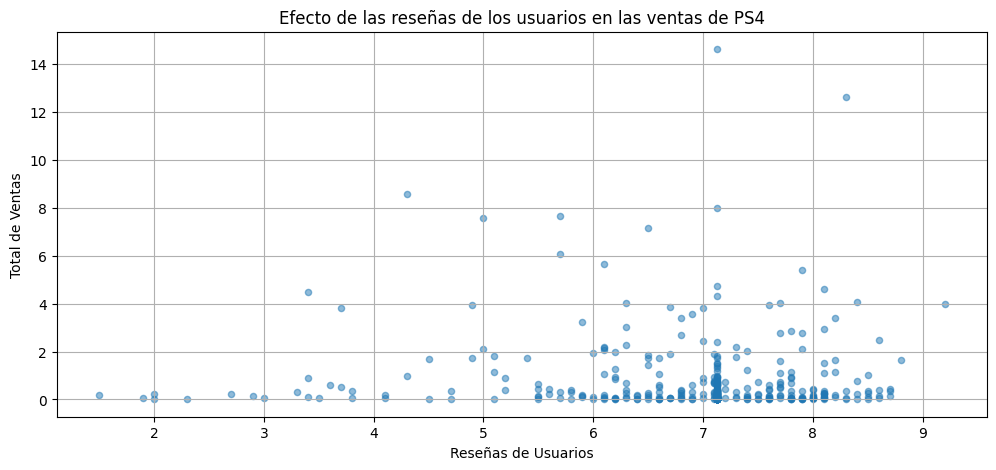


Correlación entre las reseñas de los usuarios y las ventas de PS4:
             user_score  total_sales
user_score     1.000000    -0.045391
total_sales   -0.045391     1.000000


In [16]:
#Segundo Reseñas de Usuarios vs Ventas Totales
df_plataforma.plot(kind="scatter", x="user_score", y="total_sales", alpha=0.5, figsize=(12,5))
plt.xlabel("Reseñas de Usuarios")
plt.ylabel("Total de Ventas")
plt.title("Efecto de las reseñas de los usuarios en las ventas de PS4")
plt.grid()
plt.show()
print()
corr_users = df_plataforma[['user_score', 'total_sales']].corr()
print(f"""Correlación entre las reseñas de los usuarios y las ventas de PS4:
{corr_users}""")


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Correcto!

Buena manera de mostrar la correlación entre las ventas y las reseñas, como bien mencionas la correlación es debil-moderada por lo que no siempre las buenas reseñas van a implicar un gran numero de ventas
</div>


### Notas:
- La correlación entre las reseñas de los usuarios y las ventas de PS4 es de -4.5%, es una correlación muy baja y negativa, esto implica que las reseñas de los usuarios no tienen un gran impacto en las ventas de los video juegos de PS4. Que sea negativa implica que las reseñas de lo usuarios son inversamente proporcionales con las ventas; en general, al subir las reseñas bajan las ventas y al bajar las reseñas, suben las ventas (pero muy ligeremante)
- La correlación entre las reseñas de los críticos y la ventas de PS4 es de 34,9%, es una correlación considerable. Esto quiere decir que las reseñas de los críticos tienen un impacto importante en las ventas de PS4. La correlación positivia implica una relación proporcional entre reseñas de críticos y ventas; al subir las reseñas suben las ventas, al bajar las reseñas bajan las ventas.

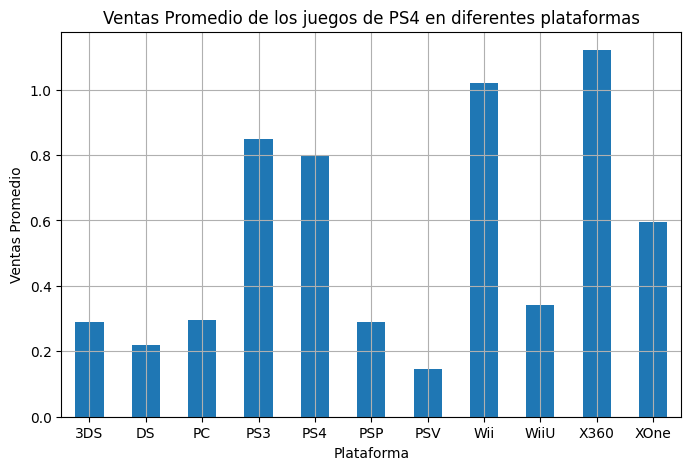


platform
3DS     0.289474
DS      0.220000
PC      0.294274
PS3     0.850393
PS4     0.801378
PSP     0.290000
PSV     0.144512
Wii     1.020000
WiiU    0.342703
X360    1.121161
XOne    0.596129
Name: total_sales, dtype: float64


In [17]:
# Ventas de juegos de la plataforma elegida en otras plataformas
juegos_unicos_plataforma = df_plataforma["name"].unique()
df_mismos_juegos = df_games_desde_2007[df_games_desde_2007['name'].isin(juegos_unicos_plataforma)]
ventas_promedio_plat = df_mismos_juegos.groupby(["platform"])["total_sales"].mean()

ventas_promedio_plat.plot(kind="bar", rot=0, title="Ventas Promedio de los juegos de PS4 en diferentes plataformas", figsize=(8, 5))
plt.xlabel("Plataforma")
plt.ylabel("Ventas Promedio")
plt.grid()
plt.show()

print()
print(ventas_promedio_plat)


### Notas:
- Las plataformas X360 y Wii tienen mayores ventas promedio en los mismos juegos de la PS4. Este resultado tiene sentido ya que X360 y Wii fueron las consolas con mayores ventas durante más tiempo que la PS4 y es probable que algunos de los juegos que se comercializaban en PS4 también estuvieran disponibles en X360 y Wii.

## 3.5. Juegos por Género

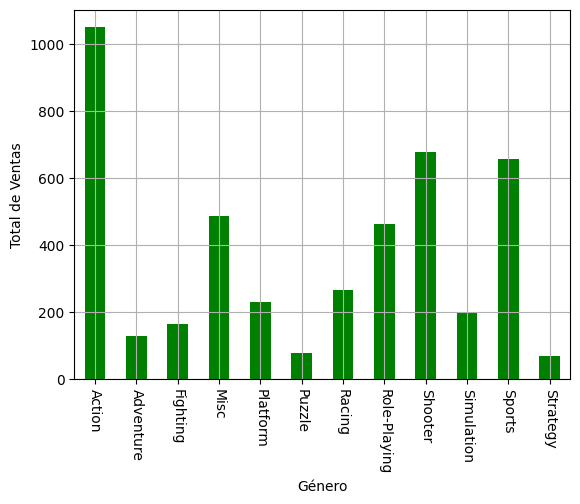


genre
Action          1050.59
Shooter          678.80
Sports           658.07
Misc             487.89
Role-Playing     465.03
Racing           265.19
Platform         230.45
Simulation       199.13
Fighting         166.00
Adventure        129.99
Puzzle            79.18
Strategy          68.99
Name: total_sales, dtype: float64


In [18]:
#Juegos por género
juegos_por_genero = df_games_desde_2007.groupby("genre")["total_sales"].sum()
juegos_por_genero.plot(kind="bar", color="green", rot=-90)
plt.xlabel("Género")
plt.ylabel("Total de Ventas")
plt.grid()
plt.show()
print()
print(juegos_por_genero.sort_values(ascending=False))

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Correcto!

Buena manera de presentar los datos, podemos ver claramente cuales son los géneros preferidos de las personas, las observaciones que haces me parecen buenas también
</div>


### Notas:
- El género de video juego más rentable, por mucho, es el de acción con al rededor de 400 millones de diferencia respecto al segundo más rentable, Shooter.
- En general, los usuarios prefieren juegos de acción, disparos y deportes, en cambio, los juegos de estrategia y acertijo están muy por debajo. Es muy recomendable producir un video juego de acción, disparos y/o deportes para obtener ventas significativas.

# 4. Perfil de Usuario por Región

## 4.1. Norte América

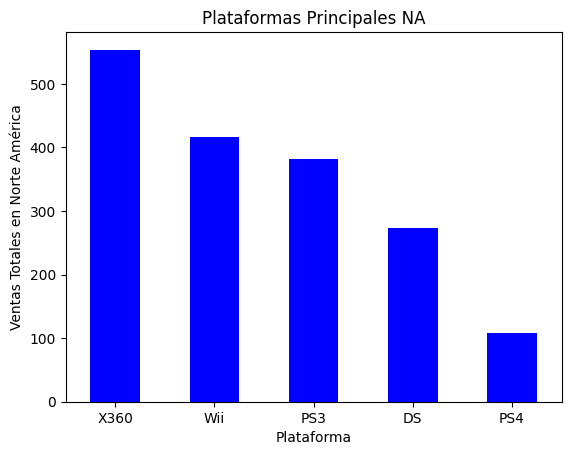

platform
X360    553.68
Wii     416.01
PS3     381.29
DS      273.98
PS4     108.74
Name: na_sales, dtype: float64

Promedio de ventas en NA: 346.73999999999955


In [19]:
# 5 plataformas principales
top_5p_na = df_games_desde_2007.groupby("platform")["na_sales"].sum().sort_values(ascending=False).head()
top_5p_na.plot(kind="bar", color="blue", title="Plataformas Principales NA", rot=0)
plt.xlabel("Plataforma")
plt.ylabel("Ventas Totales en Norte América")
plt.show()
print(top_5p_na)
print()
print(f"Promedio de ventas en NA: {top_5p_na.mean()}")

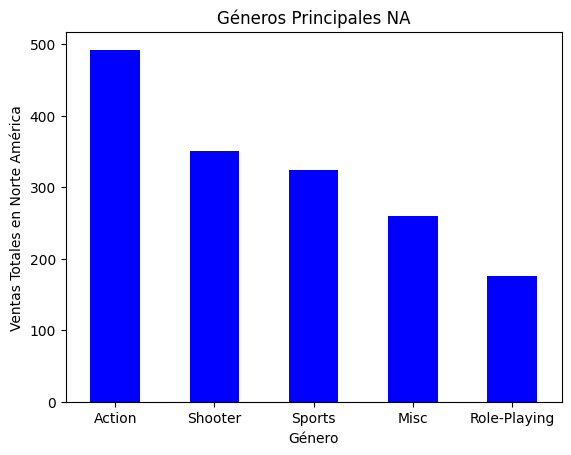

genre
Action          492.17
Shooter         350.11
Sports          323.86
Misc            259.16
Role-Playing    175.41
Name: na_sales, dtype: float64

Promedio de ventas en NA: 320.1419999999992


In [20]:
# 5 Géneros Principales
top_5g_na = df_games_desde_2007.groupby("genre")["na_sales"].sum().sort_values(ascending=False).head()
top_5g_na.plot(kind="bar", color="blue", title="Géneros Principales NA", rot=0)
plt.xlabel("Género")
plt.ylabel("Ventas Totales en Norte América")
plt.show()
print(top_5g_na)
print()
print(f"Promedio de ventas en NA: {top_5g_na.mean()}")

## 4.2. Unión Europea

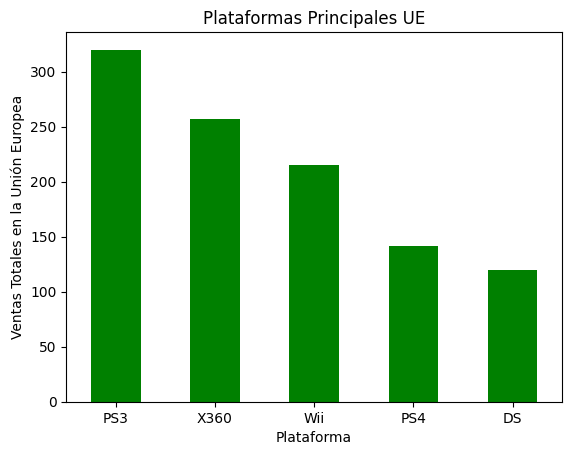

platform
PS3     319.83
X360    257.05
Wii     214.70
PS4     141.09
DS      119.92
Name: eu_sales, dtype: float64

Promedio de ventas en UE: 210.51799999999957


In [21]:
# 5 plataformas principales
top_5p_eu = df_games_desde_2007.groupby("platform")["eu_sales"].sum().sort_values(ascending=False).head()
top_5p_eu.plot(kind="bar", color="green", title="Plataformas Principales UE", rot=0)
plt.xlabel("Plataforma")
plt.ylabel("Ventas Totales en la Unión Europea")
plt.show()
print(top_5p_eu)
print()
print(f"Promedio de ventas en UE: {top_5p_eu.mean()}")

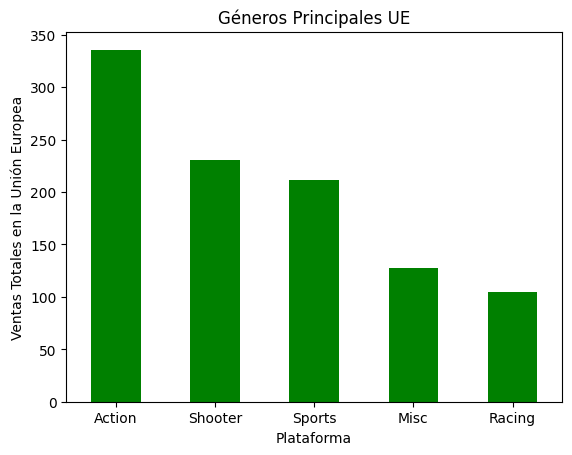

genre
Action     335.67
Shooter    230.16
Sports     211.49
Misc       127.62
Racing     104.63
Name: eu_sales, dtype: float64

Promedio de ventas en EU: 201.91399999999888


In [22]:
# 5 Géneros Principales
top_5g_eu = df_games_desde_2007.groupby("genre")["eu_sales"].sum().sort_values(ascending=False).head()
top_5g_eu.plot(kind="bar", color="green", title="Géneros Principales UE", rot=0)
plt.xlabel("Plataforma")
plt.ylabel("Ventas Totales en la Unión Europea")
plt.show()
print(top_5g_eu)
print()
print(f"Promedio de ventas en EU: {top_5g_eu.mean()}")

## 4.3. Japón

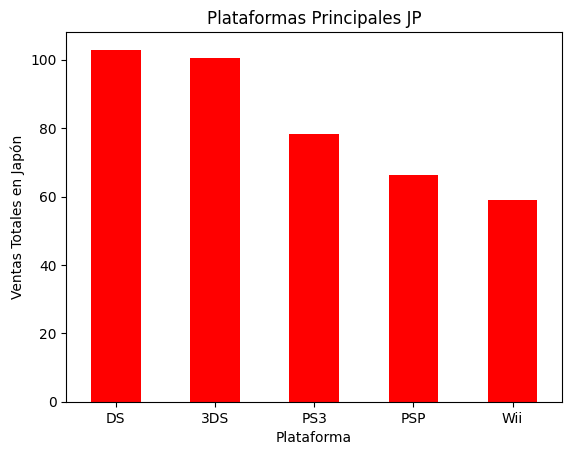

platform
DS     102.93
3DS    100.62
PS3     78.33
PSP     66.24
Wii     59.13
Name: jp_sales, dtype: float64

Promedio de ventas en JP: 81.45000000000007


In [23]:
# 5 plataformas principales
top_5p_jp = df_games_desde_2007.groupby("platform")["jp_sales"].sum().sort_values(ascending=False).head()
top_5p_jp.plot(kind="bar", color="Red", title="Plataformas Principales JP", rot=0)
plt.xlabel("Plataforma")
plt.ylabel("Ventas Totales en Japón")
plt.show()
print(top_5p_jp)
print()
print(f"Promedio de ventas en JP: {top_5p_jp.mean()}")

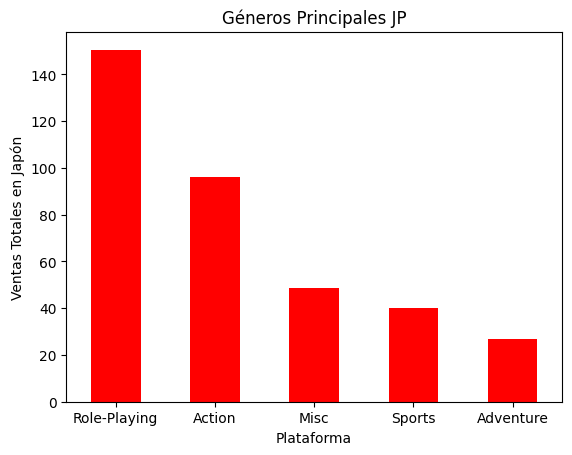

genre
Role-Playing    150.55
Action           96.29
Misc             48.79
Sports           40.28
Adventure        26.91
Name: jp_sales, dtype: float64

Promedio de ventas en JP: 72.56400000000022


In [24]:
# 5 Géneros Principales
top_5g_jp = df_games_desde_2007.groupby("genre")["jp_sales"].sum().sort_values(ascending=False).head()
top_5g_jp.plot(kind="bar", color="red", title="Géneros Principales JP", rot=0)
plt.xlabel("Plataforma")
plt.ylabel("Ventas Totales en Japón")
plt.show()
print(top_5g_jp)
print()
print(f"Promedio de ventas en JP: {top_5g_jp.mean()}")

### Notas:
- En las regiones de NA y UE el top 5 de plataformas es el mismo: X360, PS4, PS3, Wii y DS; pero el orden y la cantida de ventas son diferentes. En NA el promedio de ventas en el top 5 de plataformas es de 346.74 millones de dólares, en cambio en europa es de 210.52 millones de dólares. En europa la plataforma más exitosa es la PS3 con 319.83 millones en ventas, en NA es la X360 con 553.68 milloes. Ahora, en JP las plataformas principales son: DS, 3DS, PS3, PSP y Wii. En esta región el promedio de ventas es de 81.45 millones de dólares. Se observa que las ventas de NA son considerablemente mayores que las de EU y JP combinadas, esto muestra que NA es un mercado altamente rentable.
- Los géneros de NA y EU son casi iguales, siendo los más famosos "Action", "Shooter" y "Sports", esto muestra que ambos mercados tienen intereses muy simialres y, en general, los mismos juegos se vuelven muy famosos. Pero en Japón los juegos de rol son los líderes aboslutos, muy por encima de los de acción. Esto muestra una diferencia cultural y de intereses grande entre el mercado oriental y occidental.

## 4.4. Clasificaciones ESRB

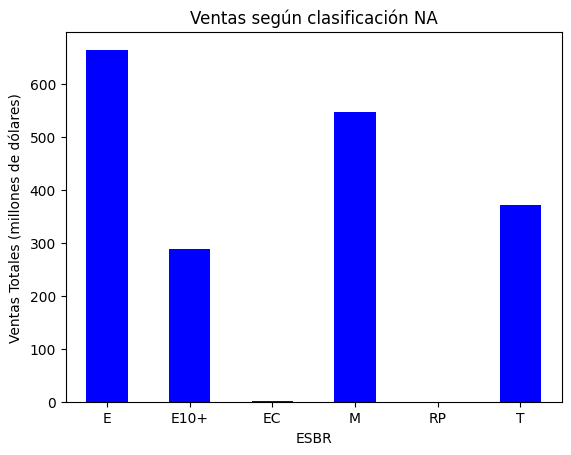

rating
E       663.99
E10+    287.61
EC        1.32
M       546.55
RP        0.00
T       371.32
Name: na_sales, dtype: float64


In [25]:
# ESRB vs Ventas NA
ventas_rating_na = df_games_desde_2007.groupby("rating")["na_sales"].sum()
ventas_rating_na.plot(kind="bar", color="blue", title="Ventas según clasificación NA", rot=0)
plt.xlabel("ESBR")
plt.ylabel("Ventas Totales (millones de dólares)")
plt.show()
print(ventas_rating_na)

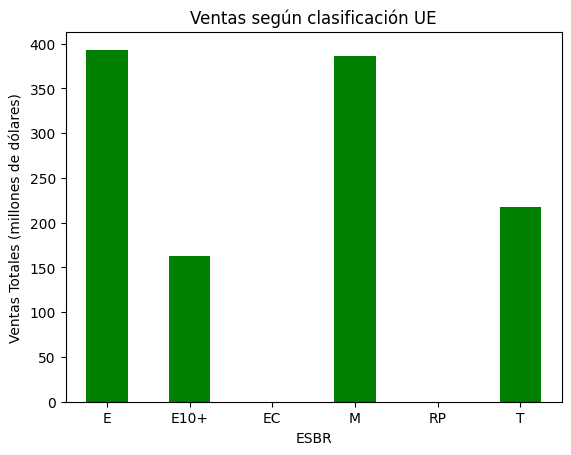

rating
E       393.08
E10+    162.75
EC        0.00
M       385.86
RP        0.03
T       217.89
Name: eu_sales, dtype: float64


In [26]:
# ESRB vs Ventas UE
ventas_rating_eu = df_games_desde_2007.groupby("rating")["eu_sales"].sum()
ventas_rating_eu.plot(kind="bar", color="green", title="Ventas según clasificación UE", rot=0)
plt.xlabel("ESBR")
plt.ylabel("Ventas Totales (millones de dólares)")
plt.show()
print(ventas_rating_eu)

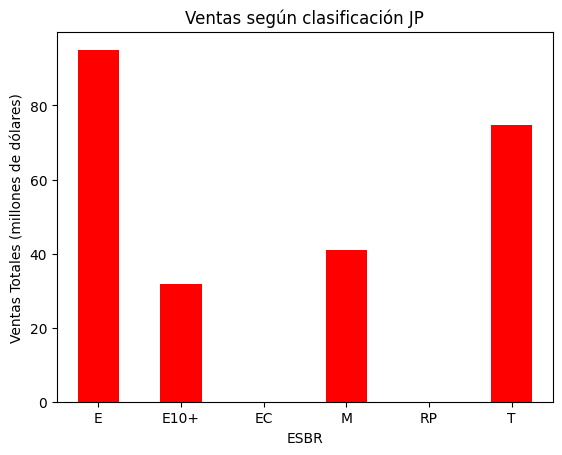

rating
E       95.06
E10+    31.91
EC       0.00
M       41.09
RP       0.00
T       74.74
Name: jp_sales, dtype: float64


In [27]:
# ESRB vs Ventas JP
ventas_rating_jp = df_games_desde_2007.groupby("rating")["jp_sales"].sum()
ventas_rating_jp.plot(kind="bar", color="red", title="Ventas según clasificación JP", rot=0)
plt.xlabel("ESBR")
plt.ylabel("Ventas Totales (millones de dólares)")
plt.show()
print(ventas_rating_jp)

### Notas:
- Las ventas se ven afectadas por la clasificaión, siendo la clasificación ESRB más vendida la E (everyone) en las tres regiones.
- El comportameinto de las ventas según la clasificación en NA y UE es muy similar, la cantidad de ventas total en NA es mucho mayor, pero la distribución de ventas es similar, siendo en estas dos regiones las clasificaiones E, M y T las que tienen más ventas.
- Las clasificaciones con más ventas en Japón son E, M y T también, pero las ventas de la clasificaión M son considerablemente menor a las de las otras dos regiones, esto muestra, una vez más, una diferencia cultural y de preferencia de mercado muy marcada entre oriente y occidente.
- Las ventas para la clasificación EC (early childhood) es muy baja para las 3 regiones, siendo cero en JP y EU, y 1.32 en NA. Esto muestra un muy bajo interés del mercado en producir video juegos para niños en infancia temprana y también una muy baja demanda.
- En europa las ventas de los juegos E y los M están casi iguales, muestra que a la población de europa le gusta mucho los juegos para gente madura y no tanto los juegos para adolescentes (T). Esto deja ver que probablemente la mayoría de los usuarios de europa sean personas maduras en comparación con otras regiones

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />

Los resultados de los últimos ejercicios me parecen bastante buenos, las gráficas complementan de una manera adecuada los resultados de las tablas. La única recomendación que puedo hacer es unir la información en una sola gráfica, de esta manera será más fácil comparar las regiones
</div>


# 5. Pruebas de Hipótesis



***Primera Prueba De Hipótesis:***
- **H0** = Las calificaciones promedio de los usuarios para las plataformas Xbox One y PC son iguales
- **H1** = Las calificaciones promedio de los usuarios para las plataformas Xbox One y PC son diferentes



In [28]:
#Prueba de hipótesis
usuarios_XB1 = df_games_desde_2007.query("platform == 'XOne'")["user_score"]
usuarios_PC = df_games_desde_2007.query("platform == 'PC'")["user_score"]

alpha = 0.05
results = st.ttest_ind(usuarios_XB1, usuarios_PC)

if results.pvalue < alpha:
    print("Rechazamos H₀, las clasificaciones promedio de los usuarios de Xbox One y PX son diferentes")
else:
    print("No podemos rechazar H₀, no hay suficiente evidencia en los datos para concluir que existe una diferencia entre las clasficiaciones promedio de Xbox One y PC")

No podemos rechazar H₀, no hay suficiente evidencia en los datos para concluir que existe una diferencia entre las clasficiaciones promedio de Xbox One y PC



### Notas: 
No podemos rechazar la hipótesis nula, pero tampoco podemos afirmar 100% que no las calificaiones promedio del Xbox One y el PC son iguales; no tenemos suficiente videncia para afirmar eso, por los resultados observados probablemente se deban al azar y no a una causa real. No hay significancia estadística.


***Segunda Prueba De Hipótesis:***
- **H0** = Las calificaciones promedio de los usuarios para los géneros de Acción y Deportes son iguales
- **H1** = Las calificaciones promedio de los usuarios para los géneros de Acción y Deportes son diferentes


In [29]:
usuarios_accion = df_games_desde_2007.query("genre == 'Action'")["user_score"]
usuarios_deportes = df_games_desde_2007.query("genre == 'Sports'")["user_score"]

alpha = 0.05
results = st.ttest_ind(usuarios_XB1, usuarios_PC)

if results.pvalue < alpha:
    print("Rechazamos H₀, las clasificaciones promedio de los usuarios para los géneros de Acción y Deportes son diferentes")
else:
    print("No podemos rechazar H₀, no hay suficiente evidencia en los datos para concluir que existe una diferencia entre las clasficiaciones promedio de los géneros de Acción y Deportes")

No podemos rechazar H₀, no hay suficiente evidencia en los datos para concluir que existe una diferencia entre las clasficiaciones promedio de los géneros de Acción y Deportes


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />


El planteamiento de la hipótesis me parece correcto en ambos casos, bien hecho!
</div>


### Notas: 
No podemos rechazar la hipótesis nula, pero tampoco podemos afirmar 100% que no las calificaiones promedio de los usuarios de los géneros de Accipon y Deportes son iguales; no tenemos suficiente videncia para afirmar eso, por los resultados observados probablemente se deban al azar y no a una causa real. No hay significancia estadística.


# 6. Conclusión general

Primero, el período relevante para mi análisis fue desde el 2007 basado en una vida útil de los video juegos/consolas de 10 años. Antes de 2007 hay muy pocos datos para la gran mayoría de consolas y lo juegos lanzados, las ventas no eran tan grandes como lo son en e período de astudio ni los juegos lanzados por año. Este período de 2007-2016 es perfecto para observar la tendecia del mercado y predecir para el 2017.
Segundo, las plataformas más prometedoras son la _Xbox One_ y la _PS4_, que muestran una posible tendencia a crecer y son la sdos plataformas más importantes actualmente. Entre las menos prometedoras están la Wii y la WiiU, estas plataformas han pasado su vida útil (10 años) y sus ventas son considerablemente menores a lo que solían ser.
Tercero, si bien los géneros más relevantes cambian dependiendo de la región, hay dos géneros que se repiten y son _Acción_ y _Deportes_. Estos géneros están presentes en las tres regiones más importantes del mundo y tienen una gran cantidad de las ventas totales regionales.
Cuarto, las reseñas de los críticos de video juegos tienen un gran impacto en las ventas de estos, una buena crítica puede aumnetar hasta en un _35%_ las ventas de una entrega, por lo que es recomendable estudiar los aspectos que los críticos evaluan a la hora de producir un video juego para garantizar una buena acogida y, por lo tanto, el éxito del mismo. Los datos también mostraron que no hay suficiente evidencia para concluir que las clasificaciones de los usuarios sobre las consolas y los géneros de los video juegos sean iguales.
Para la campaña de 2017 recomiendo a la tienda online:
- Enfocarse en vender video juegos de _PS4_ y _Xbox_ One principalmente, sin dejar de la los juegos de PC.
- Promover principalmente los video juegos de _acción_ y _deportes_, y acompañarlos con juegos de _rol_, _aventura_ y _miscelaneos_ para dar más variedad al catálogo.
- Invertir en los video juegos con mejores reseñas de los críticos y usar marketing para mostrar esta calificación a los usuarios.


## Comentario general del revisor
<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Has realizado un buen trabajo, me doy cuenta de que has aplicado los conocimientos que has adquirido durante el curso, las observaciones que has hecho durante todo el ejercicio me han parecido bastante buenas, son un gran apoyo a la hora de revisar el proyecto ya que me dan a entender que el tema te ha quedado claro y has podido avanzar correctamente.

    
Continúa con el buen trabajo y mucho éxito en el siguiente Sprint!
</div>


<div class="alert alert-block alert-success">
<b>Aspectos positivos del proyecto</b> <a class="tocSkip"></a><br />

- Las observaciones intermedias, así como las conclusiones finales me parecen buenas
- Las graficas utilizadas me parecen del tipo correcto
- El proyecto esta ordenado y limpio
    
</div>
